# CIFAR-10 Transfer Learning with ResNet50

This notebook builds the classification model required in the assignment. It uses transfer learning with ResNet50 pretrained on ImageNet, trains a custom classification head, then unfreezes the base model and fine-tunes the full network.

## Objectives
- load CIFAR-10 and preprocess the images
- initialize ResNet50 with ImageNet weights and `input_shape=(32, 32, 3)`
- freeze the base model and train a custom head for 10 epochs
- unfreeze the base model and fine-tune for 10 more epochs
- evaluate performance on the test set
- document observations, reasoning, and limitations


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)


## 1. Load and preprocess CIFAR-10

We load the dataset using Keras, keep the variable names requested by the assignment, and then preprocess the images using the ResNet50-specific preprocessing function.


In [26]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

train_images_preprocessed = preprocess_input(train_images.astype('float32'))
test_images_preprocessed = preprocess_input(test_images.astype('float32'))

print('train_images shape:', train_images.shape)
print('test_images shape:', test_images.shape)
print('train_images_preprocessed shape:', train_images_preprocessed.shape)
print('test_images_preprocessed shape:', test_images_preprocessed.shape)


train_images shape: (50000, 32, 32, 3)
test_images shape: (10000, 32, 32, 3)
train_images_preprocessed shape: (50000, 32, 32, 3)
test_images_preprocessed shape: (10000, 32, 32, 3)


## 2. Build the base model

The assignment specifically asks for ResNet50 with `weights='imagenet'` and `input_shape=(32, 32, 3)`. We also set `include_top=False` because we are replacing the original ImageNet classifier with a custom head for CIFAR-10.

At this stage, we freeze the base model so the pretrained convolutional layers are not updated during the initial head-training phase.


In [27]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

base_model.trainable = False

print('Base model created successfully.')
print('Base model trainable:', base_model.trainable)


Base model created successfully.
Base model trainable: False


## 3. Build the classification head

We add a small custom head on top of the pretrained CNN. This head transforms the extracted visual features into predictions for the 10 CIFAR-10 classes.

Design choices:
- `GlobalAveragePooling2D` reduces the spatial feature maps into a compact vector
- `BatchNormalization` can help stabilize training
- `Dense` layers learn the CIFAR-10-specific representation
- `Dropout` is included to reduce overfitting


In [28]:
inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,154,634 (92.14 MB)

 Trainable params: 562,826 (2.15 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 4. Compile the model

We use the Adam optimizer and sparse categorical crossentropy because the labels are integer-encoded rather than one-hot encoded. Accuracy is used as a simple and interpretable primary metric.


In [29]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 5. Train the custom head for 10 epochs

In this phase, only the custom head is trained. This allows the randomly initialized top layers to adapt to CIFAR-10 without immediately modifying the pretrained convolutional feature extractor.


In [30]:
head_history = model.fit(
    train_images_preprocessed,
    train_labels,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.5210 - loss: 1.3998 - val_accuracy: 0.6306 - val_loss: 1.0908
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.6086 - loss: 1.1297 - val_accuracy: 0.6501 - val_loss: 1.0198
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6411 - loss: 1.0282 - val_accuracy: 0.6606 - val_loss: 0.9959
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6678 - loss: 0.9489 - val_accuracy: 0.6682 - val_loss: 0.9798
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6901 - loss: 0.8839 - val_accuracy: 0.6682 - val_loss: 0.9705
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7089 - loss: 0.8233 - val_accuracy: 0.6715 - val_loss: 0.9835
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.7269 - loss: 0.7654 - val_accuracy: 0.6694 - val_loss: 0.9894
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.7450 - loss: 0.7138 - 

Evaluating test results before fine tuning.

In [31]:
test_loss, test_accuracy = model.evaluate(test_images_preprocessed, test_labels, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6617 - loss: 1.0754
Test Loss: 1.0754
Test Accuracy: 0.6617


## 6. Unfreeze the base model and fine-tune

After the classifier head has learned a reasonable mapping, we unfreeze the base model and train the full network. This stage is called fine-tuning.

Important change: we use a **smaller learning rate** during fine-tuning. This is standard practice because we want to adjust pretrained weights carefully rather than overwrite useful learned features too aggressively.


In [32]:
base_model.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Base model trainable after unfreezing:', base_model.trainable)


Base model trainable after unfreezing: True


In [33]:
fine_tune_history = model.fit(
    train_images_preprocessed,
    train_labels,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 283s 434ms/step - accuracy: 0.3812 - loss: 2.0984 - val_accuracy: 0.4622 - val_loss: 1.6930
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 283s 452ms/step - accuracy: 0.5368 - loss: 1.3573 - val_accuracy: 0.5018 - val_loss: 1.5435
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1196s 2s/step - accuracy: 0.6498 - loss: 1.0010 - val_accuracy: 0.5291 - val_loss: 1.4776
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1745s 3s/step - accuracy: 0.7301 - loss: 0.7694 - val_accuracy: 0.5467 - val_loss: 1.4481
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 406ms/step - accuracy: 0.7877 - loss: 0.6090 - val_accuracy: 0.5592 - val_loss: 1.4455
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3302s 5s/step - accuracy: 0.8372 - loss: 0.4807 - val_accuracy: 0.5697 - val_loss: 1.4439
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 557s 891ms/step - accuracy: 0.8742 - loss: 0.3864 - val_accuracy: 0.5772 - val_loss: 1.4681
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 256s 409ms/step - accuracy: 0.9000 - loss:

## 7. Evaluate on the test set

We evaluate the final model on the held-out test set to estimate how well it generalizes to unseen data.


In [34]:
test_loss, test_accuracy = model.evaluate(test_images_preprocessed, test_labels, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5939 - loss: 1.5836
Test Loss: 1.5836
Test Accuracy: 0.5939


## 8. Plot training history

Visualizing the learning curves makes it easier to discuss training stability, convergence, and possible overfitting in your final presentation.


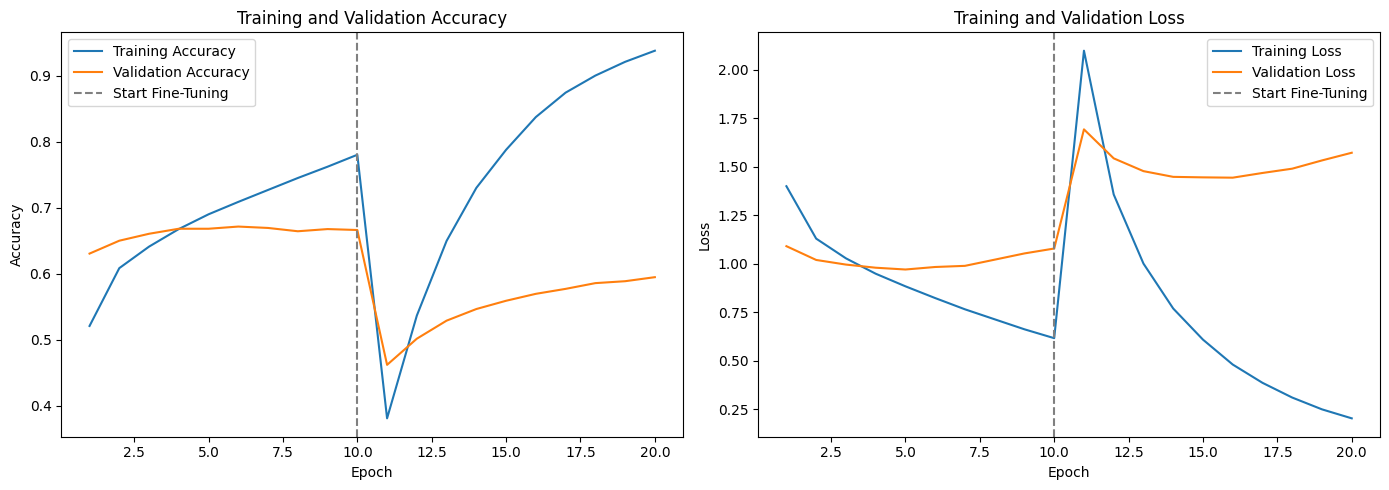

In [35]:
head_acc = head_history.history['accuracy']
head_val_acc = head_history.history['val_accuracy']
head_loss = head_history.history['loss']
head_val_loss = head_history.history['val_loss']

fine_acc = fine_tune_history.history['accuracy']
fine_val_acc = fine_tune_history.history['val_accuracy']
fine_loss = fine_tune_history.history['loss']
fine_val_loss = fine_tune_history.history['val_loss']

all_acc = head_acc + fine_acc
all_val_acc = head_val_acc + fine_val_acc
all_loss = head_loss + fine_loss
all_val_loss = head_val_loss + fine_val_loss
epochs_range = range(1, len(all_acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, all_acc, label='Training Accuracy')
plt.plot(epochs_range, all_val_acc, label='Validation Accuracy')
plt.axvline(x=10, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, all_loss, label='Training Loss')
plt.plot(epochs_range, all_val_loss, label='Validation Loss')
plt.axvline(x=10, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## 9. Classification report and confusion matrix

These diagnostics help interpret where the model performs well and where it confuses classes. That is useful for demonstrating reasoning beyond a single accuracy number.


In [36]:
pred_probs = model.predict(test_images_preprocessed, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = test_labels.flatten()

print(classification_report(true_labels, pred_labels, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step
              precision    recall  f1-score   support

    airplane       0.61      0.66      0.63      1000
  automobile       0.68      0.63      0.65      1000
        bird       0.51      0.51      0.51      1000
         cat       0.43      0.41      0.42      1000
        deer       0.53      0.54      0.53      1000
         dog       0.56      0.52      0.54      1000
        frog       0.62      0.71      0.66      1000
       horse       0.66      0.59      0.62      1000
        ship       0.67      0.73      0.70      1000
       truck       0.67      0.64      0.66      1000

    accuracy                           0.59     10000
   macro avg       0.59      0.59      0.59     10000
weighted avg       0.59      0.59      0.59     10000



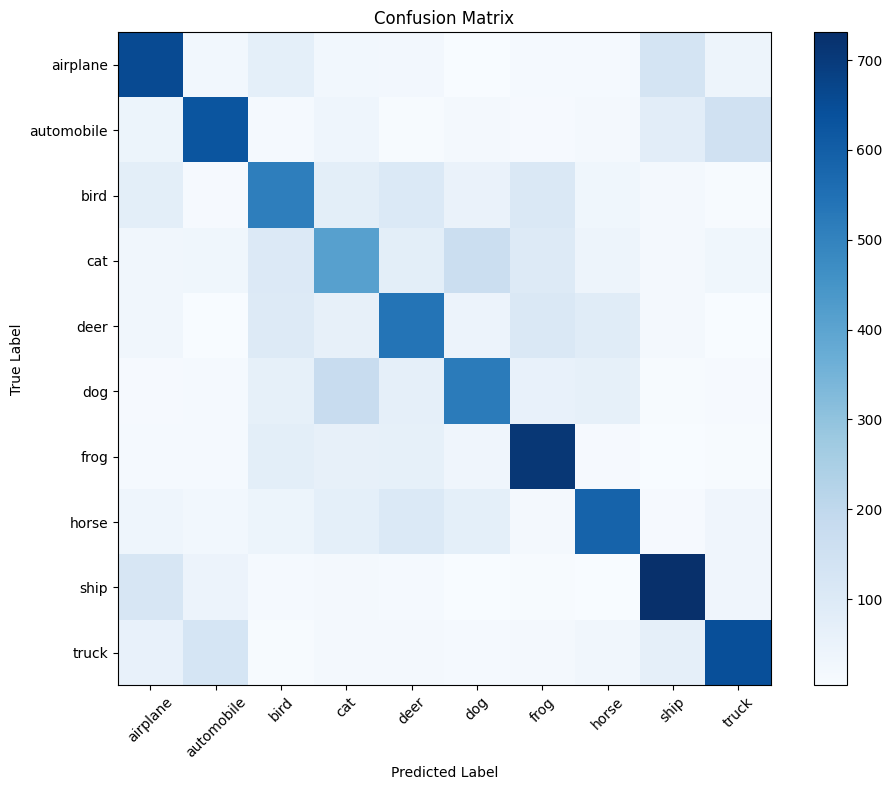

In [37]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


## 10. Analytical discussion

### What changed between training the head and fine-tuning the full model
- In the first phase, only the custom classifier layers were trainable. This allowed the model to adapt to CIFAR-10 without changing the pretrained convolutional filters.
- In the second phase, the full base model was unfrozen and trained with a lower learning rate. This allowed the pretrained visual features to adjust to the CIFAR-10 domain.
- Fine-tuning often improves performance, but it also increases training time and can increase overfitting risk if not handled carefully.

### Observations during training
- If training accuracy rises while validation accuracy stays flat or drops, that suggests overfitting.
- If both training and validation improve after unfreezing, that suggests fine-tuning is helping the pretrained features adapt better.
- If progress is slow, that is expected in computer vision tasks, especially without GPU acceleration.

### Constraints and limitations
- CIFAR-10 images are very small, which makes the classification task difficult.
- ResNet50 was originally pretrained on larger ImageNet images, so using 32×32 inputs is not necessarily ideal from a modeling perspective, but it matches the assignment requirement.
- Runtime can be long on CPU. Fine-tuning the full model is especially expensive.

### What could be improved next
- train for more epochs
- use callbacks such as early stopping and model checkpointing
- try data augmentation
- experiment with different head architectures or regularization settings
- compare ResNet50 with smaller pretrained backbones that may be more efficient on CIFAR-10


## 11. Presentation talking points

For the live presentation, you can explain the project using this sequence:
1. CIFAR-10 is challenging because images are tiny and some classes are visually similar.
2. The pipeline was: load data → preprocess for ResNet50 → train custom head → fine-tune full model → evaluate.
3. Transfer learning was used to benefit from features learned on ImageNet.
4. Freezing first made training more stable; unfreezing later allowed the feature extractor to adapt.
5. Main trade-offs included runtime, hardware limitations, and the mismatch between CIFAR-10 image size and the original ResNet50 pretraining setup.
